# Market Risk Project 2025-2026

**Authors:** Matthieu HANNA GERGUIS & Renaud DE L'EPINE  
**Class:** A4-IF3  
**Professor:** Nicolas PESCI  

---

### Project Overview
This notebook contains the complete work for the *Market Risk Project (2025–2026)* and will be complemented by a final written report. It includes the implementation of the methods studied in class, the numerical results, and their interpretation.

Throughout this project, we chose to use **Git and GitHub** to manage our work. This allowed us to save our progress regularly, track changes over time, and keep the project well-organized and reproducible. This choice was made deliberately to stay as close as possible to professional and industry practices, and to develop good working habits.

The GitHub repository for this project is available at: https://github.com/MatthieuHannaGerguis/MarketRisk_Project_Hanna_Gerguis_DeLEpine

### Reading Guide - Code Colour Convention Used in This Notebook

To facilitate reading and correction, we use a **code colour convention** throughout the notebook.  
This allows you to immediately distinguish between course-related elements, our own analysis, and practical or methodological remarks.

The following colour code is used consistently:

> <span style="color:#1f4fd8"><strong>Theory</strong></span>  
> <span style="color:#1f4fd8">Course content, definitions, formulas, and theoretical reminders.</span>

> <span style="color:#0b7a3e"><strong>Analysis</strong></span>  
> <span style="color:#0b7a3e">Interpretation of results, discussion, and financial intuition.</span>

> <span style="color:#7a3e0b"><strong>Remark</strong></span>  
> <span style="color:#7a3e0b">Practical notes, assumptions, limitations, and methodological choices.</span>

### Project Structure
The project is organized question by question, following the project statement.  
Throughout the notebook, a consistent structure is used to clearly distinguish course-related elements, the implementation, the numerical results, and their interpretation.

We now start with Question A.

---


### Question A - Historical Value at Risk (VaR)

The objective of this question is to estimate the market risk of the Natixis stock using a historical, non-parametric approach to Value at Risk (VaR).

#### I. Data preparation and return computation

We start by loading the Natixis price data provided for the project and computing daily returns from prices, after applying only basic transformations such as date parsing and chronological ordering.

<span style="color:#7a3e0b"><strong>Remark:</strong> The same dataset "Natixis_stock" and return series will be used in Questions B and C, so the data preparation is done once and kept unchanged throughout these questions.</span>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Preprocessing
data = pd.read_csv("../data/Natixis_stock.txt", delimiter='\t', 
                   header=None, parse_dates=[0]) #We will mainly use main dataframe to analyze data in our whole project
data.columns = ['Date', 'Value'] #We will tend to always rename columns
data['Date'] = pd.to_datetime(data['Date'], format="%d/%m/%Y") 

#Preprocessing of date-time
data['Value'] = data['Value'].str.replace(',', '.').astype(float) #Re type float number as we read a txt, the coma point transition isn't immediate
data = data.sort_values('Date') # For now let's sort by date to calculate returns coherent we use build in sort algorithm.

#Compute of Returns in data frame and creating new column, the shift()
#function just go to the next row in the same column, we didn't use pct_change() a builded in function of pandas
def Returns(data):
    data['Returns'] = (data['Value'] - data['Value'].shift(1)) / data['Value'].shift(1)
    return data

#Let's compute returns based on sorted date (which is the good sort)
data = Returns(data)
print(data)

#As we can see the first value of returns is NaN which is logical due to the definition of returns so we decide to erase the row from our dataset
data = data.dropna()
print(data)

#Let's define some value alpha is the probability level targeted and value portfolio is the actual value of the portfolio
alpha = 0.05
value_portfolio = 100000

           Date  Value   Returns
0    2015-01-02  5.621       NaN
1    2015-01-05  5.424 -0.035047
2    2015-01-06  5.329 -0.017515
3    2015-01-07  5.224 -0.019704
4    2015-01-08  5.453  0.043836
...         ...    ...       ...
1018 2018-12-21  4.045 -0.001481
1019 2018-12-24  4.010 -0.008653
1020 2018-12-27  3.938 -0.017955
1021 2018-12-28  4.088  0.038090
1022 2018-12-31  4.119  0.007583

[1023 rows x 3 columns]
           Date  Value   Returns
1    2015-01-05  5.424 -0.035047
2    2015-01-06  5.329 -0.017515
3    2015-01-07  5.224 -0.019704
4    2015-01-08  5.453  0.043836
5    2015-01-09  5.340 -0.020723
...         ...    ...       ...
1018 2018-12-21  4.045 -0.001481
1019 2018-12-24  4.010 -0.008653
1020 2018-12-27  3.938 -0.017955
1021 2018-12-28  4.088  0.038090
1022 2018-12-31  4.119  0.007583

[1022 rows x 3 columns]


Bonus: As a preliminary step, we represent the evolution of the Natixis stock price over time. This simple visualization is provided only to better understand the data we are working with, before moving to the risk estimation.

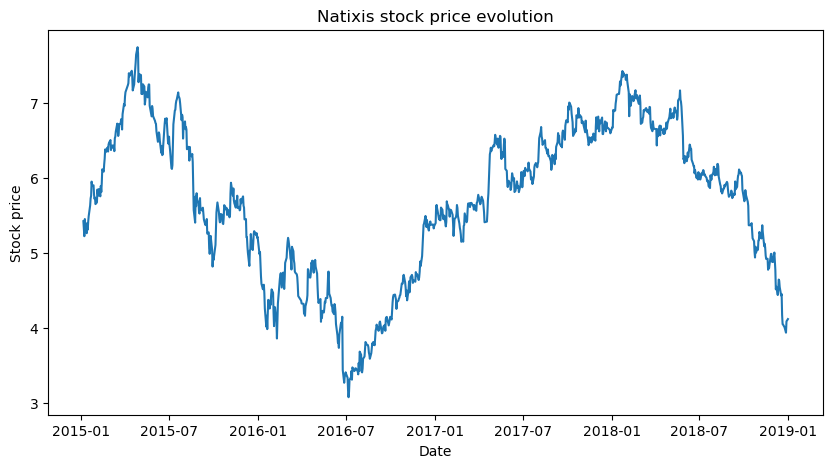

In [14]:
# Simple visualization of the Natixis stock price over time
plt.figure(figsize=(10, 5))
plt.plot(data["Date"], data["Value"])
plt.xlabel("Date")
plt.ylabel("Stock price")
plt.title("Natixis stock price evolution")
plt.show()

We observe the usual fluctuations of a financial asset, which motivates the use of quantitative risk measures in the following sections.

#### II. Historical VaR estimation

We now estimate the historical Value at Risk using a non-parametric approach based on kernel density estimation, as introduced during the lectures.

In [8]:
#Now, on our sorted dataset, we select the time periods required to estimate and validate the historical VaR.
data_date_sort_2015 = data[(data["Date"] >= '2015-01-01') & (data["Date"] <= '2016-12-31')]
data_date_sort_2017 = data[(data["Date"] >= '2017-01-01') & (data["Date"] <= '2018-12-31')]

#Once the selection is done now we can sort returns !
data_date_sort_2015 = data_date_sort_2015.sort_values("Returns") # using build in sort function of pandas
data_date_sort_2017 = data_date_sort_2017.sort_values("Returns")

print(data_date_sort_2015) # quick check up

          Date  Value   Returns
378 2016-06-24  3.439 -0.171325
345 2016-05-10  4.083 -0.069083
358 2016-05-27  4.460 -0.061448
405 2016-08-02  3.422 -0.060664
277 2016-02-02  4.208 -0.058613
..         ...    ...       ...
283 2016-02-10  4.101  0.062435
305 2016-03-11  5.083  0.063389
164 2015-08-25  5.755  0.064755
403 2016-07-29  3.685  0.075912
326 2016-04-13  4.785  0.078431

[512 rows x 3 columns]


<span style="color:#1f4fd8"> We first recall the definition of the historical Value at Risk as introduced during the lectures (see slide on Value at Risk, page 68). </span>

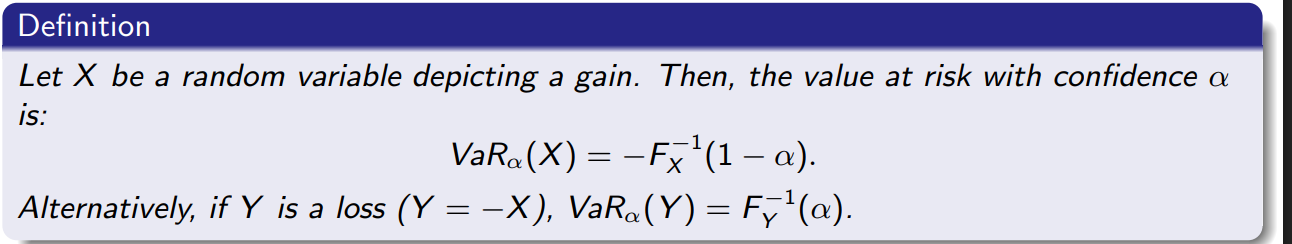

<span style="color:#7a3e0b"><strong>Remark:</strong> We estimate the VaR as the empirical α-quantile of the return distribution, consistently with the definition introduced during the lectures.</span>

In [11]:
# Historical VaR estimation using the empirical quantile
var_historical = np.quantile(data_date_sort_2015["Returns"], alpha)

# VaR expressed in monetary value
var_historical_value = - var_historical * value_portfolio

var_historical, var_historical_value

(np.float64(-0.03777913198405718), np.float64(3777.9131984057176))

This value corresponds to the maximum expected one-day loss at the 5% confidence level, based on historical returns observed between 2015 and 2016.

We now refine the estimation by using a kernel-based non-parametric approach, as required in the project statement.

We use a biweight kernel to estimate the return distribution; 
<span style="color:#1f4fd8"> the kernel density estimation is then used to approximate the distribution and extract the corresponding quantile, as introduced during the lectures (see slide on VaR estimation, page 69). </span>

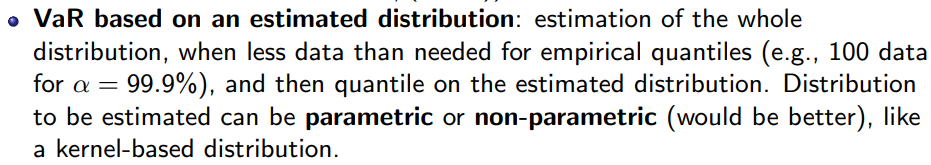

In [12]:
# We define the biweight kernel used in the non-parametric estimation
def kernel(u):
    if abs(u) <= 1:
        return (15/16) * (1 - u**2)**2
    else:
        return 0

# Kernel density estimation function
# data corresponds to the return series and x is the point where the density is evaluated
def kernel_density(data, x):
    
    # Bandwidth chosen using a rule-of-thumb (Silverman's type formula)
    h = ((4 * data['Returns'].std()) / (3 * len(data['Returns'])))**0.2

    n = len(data['Returns'])
    kernel_sum = 0

    # We sum the contribution of each observation to the kernel density
    for r in data['Returns']:
        kernel_sum += kernel((x - r) / h)

    # Final kernel density value
    return kernel_sum / (n * h)

# Function to compute the non-parametric VaR using the kernel-based distribution
def VaR_Kernel(data, alpha):
    
    probabilities = []
    # We compute the kernel density associated with each return

    for r in data['Returns']:
        probabilities.append(kernel_density(data, r))

    # Normalization to ensure probabilities sum to one
    total = sum(probabilities)
    if total != 0:
        probabilities = [p / total for p in probabilities]

    # Computation of the empirical quantile based on cumulative probabilities
    sorted_returns = sorted(data['Returns'])
    cumulative_prob = 0

    for i, p in enumerate(probabilities):
        cumulative_prob += p
        if cumulative_prob >= alpha:
            return sorted_returns[i]

# Kernel-based VaR estimation at 5% confidence level
Value_at_Risk = VaR_Kernel(data_date_sort_2015, 0.05)
print(f"Value at Risk of Kernel : {Value_at_Risk}")


Value at Risk of Kernel : -0.03478608556577359


Bonus: For illustration purposes, we display the kernel density estimate together with the return distribution and the estimated VaR.

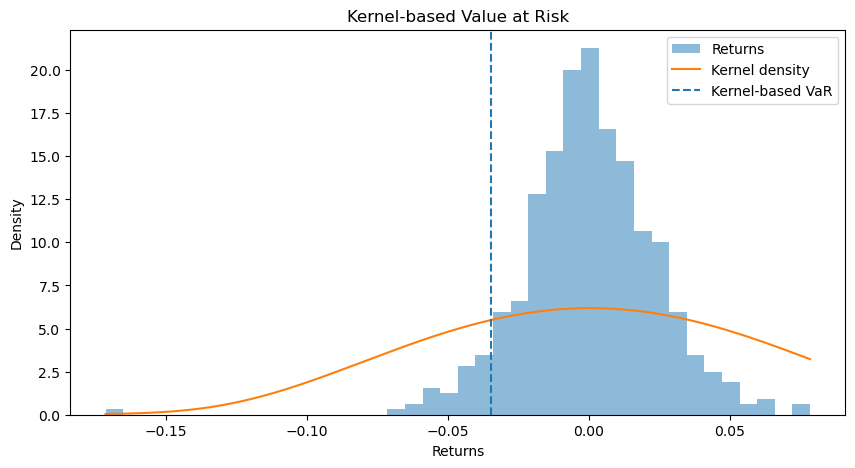

In [15]:
# Simple graphical representation to visualize the kernel-based VaR
# We only use this plot to better understand the results obtained above

plt.figure(figsize=(10, 5))

# Histogram of the returns over the 2015–2016 period
plt.hist(data_date_sort_2015["Returns"], bins=40, density=True, alpha=0.5, label="Returns")

# Grid of values used to draw the kernel density
x_values = np.linspace(
    data_date_sort_2015["Returns"].min(),
    data_date_sort_2015["Returns"].max(),
    500
)

# Kernel density evaluated on the grid
kernel_values = [kernel_density(data_date_sort_2015, x) for x in x_values]

plt.plot(x_values, kernel_values, label="Kernel density")

# Vertical line corresponding to the estimated VaR
plt.axvline(Value_at_Risk, linestyle="--", label="Kernel-based VaR")

plt.xlabel("Returns")
plt.ylabel("Density")
plt.title("Kernel-based Value at Risk")
plt.legend()
plt.show()


<span style="color:#0b7a3e">
From the graph, we can see that the estimated VaR lies in the left tail of the return distribution and remains very close to the empirical VaR computed previously, which confirms the consistency of the historical risk estimation.
</span>

#### III. Validation of the VaR threshold (Out-of-sample)

We now evaluate the proportion of returns exceeding the VaR threshold on the 2017–2018 period, in order to assess whether the non-parametric VaR estimated on 2015–2016 data remains relevant out-of-sample.

In [16]:
# We now look at how many returns exceed the VaR threshold on the 2017–2018 period
# The idea is simply to count how often losses are larger than the estimated VaR

count = 0  # we start by initializing a counter

for r in data_date_sort_2017["Returns"]:
    if r < Value_at_Risk:
        count += 1  # we count the number of exceedances

# Compute the proportion of exceedances in percentage
exceedance_rate = (count / len(data_date_sort_2017["Returns"])) * 100

print(f"Percentage of returns exceeding the VaR: {exceedance_rate}")


Percentage of returns exceeding the VaR: 1.7647058823529411


<span style="color:#0b7a3e">
We observe that the proportion of returns exceeding the VaR threshold is below the nominal confidence level of 5%, which suggests that the non-parametric VaR remains valid on the 2017–2018 period.
</span>